In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt #为了画图
%matplotlib inline

In [2]:
words=open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# 建立训练数据
block_size=3 #上下文长度，也就是模型一次能看到几个字符
X,Y=[],[]
for w in words[:5]: #只用前1000个单词来训练
    #print(w)
    context=[0]*block_size #用0来表示context的开始
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '---->', itos[ix])
        context=context[1:]+[ix] #把context向右移动，加入新的字符


X=torch.tensor(X)
Y=torch.tensor(Y)


In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
C=torch.randn(27,2)

In [8]:
emb=C[X]
emb.shape

torch.Size([32, 3, 2])

In [9]:
w1=torch.randn((6,100))
b1=torch.randn(100)

In [10]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1)

tensor([[-0.1582,  1.0134, -0.1582,  1.0134, -0.1582,  1.0134],
        [-0.1582,  1.0134, -0.1582,  1.0134, -0.2206, -0.5714],
        [-0.1582,  1.0134, -0.2206, -0.5714,  0.6815, -2.0479],
        [-0.2206, -0.5714,  0.6815, -2.0479,  0.6815, -2.0479],
        [ 0.6815, -2.0479,  0.6815, -2.0479,  1.6401, -0.0534],
        [-0.1582,  1.0134, -0.1582,  1.0134, -0.1582,  1.0134],
        [-0.1582,  1.0134, -0.1582,  1.0134,  1.1961, -1.0027],
        [-0.1582,  1.0134,  1.1961, -1.0027, -1.8133, -0.0999],
        [ 1.1961, -1.0027, -1.8133, -0.0999, -0.7988,  1.1644],
        [-1.8133, -0.0999, -0.7988,  1.1644, -1.5261,  1.9885],
        [-0.7988,  1.1644, -1.5261,  1.9885, -0.7988,  1.1644],
        [-1.5261,  1.9885, -0.7988,  1.1644,  1.6401, -0.0534],
        [-0.1582,  1.0134, -0.1582,  1.0134, -0.1582,  1.0134],
        [-0.1582,  1.0134, -0.1582,  1.0134,  1.6401, -0.0534],
        [-0.1582,  1.0134,  1.6401, -0.0534, -1.5261,  1.9885],
        [ 1.6401, -0.0534, -1.5261,  1.9

In [11]:
torch.cat(torch.unbind(emb,1),dim=1).shape

torch.Size([32, 6])

torch.cat(torch.unbind(emb,1),dim=1).shape
emb.view(-1,6)
这两个方法一样，但是优先考虑下面的，因为上面的会重新分配内存

In [12]:
h=torch.tanh(emb.view(-1,6) @ w1 + b1)
h.shape

torch.Size([32, 100])

上面有广播机制，
32,100
  ，100
这两个张量相加，会将下面的变成（1，100），

In [13]:
w2=torch.randn((100,27))
b2=torch.randn(27)
logits=h @ w2 + b2
logits.shape

torch.Size([32, 27])

In [14]:
counts=logits.exp()
prob=counts/counts.sum(1,keepdim=True)# 按照第一维度来归一化，也是一个softmax

In [15]:
loss=-prob[torch.arange(32),Y].log().mean()
loss

tensor(16.0892)

In [16]:
# 建立训练数据
block_size=3 #上下文长度，也就是模型一次能看到几个字符
X,Y=[],[]
for w in words: #只用前1000个单词来训练
    #print(w)
    context=[0]*block_size #用0来表示context的开始
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '---->', itos[ix])
        context=context[1:]+[ix] #把context向右移动，加入新的字符


X=torch.tensor(X)
Y=torch.tensor(Y)


In [17]:
## -------------------  完整步骤 -------------------
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [18]:
g=torch.Generator().manual_seed(2147483647)
C=torch.randn(27,2, generator=g)
w1=torch.randn((6,100), generator=g)
b1=torch.randn(100, generator=g)
w2=torch.randn((100,27), generator=g)
b2=torch.randn(27, generator=g)
parameters=[C,w1,b1,w2,b2]

In [19]:
sum(p.nelement() for p in parameters)

3481

In [20]:
for p in parameters:
    p.requires_grad=True

In [21]:
lre=torch.linspace(-3,0,1000)
lrs=10**lre #让变化率随指数变化


In [22]:
# lri=[]
# lossi=[]
for i in range(1000):

    #构建 mini batch
    ix=torch.randint(0,X.shape[0],(32,))
    # forward pass
    emb=C[X[ix]]  #(32,3,2)
    h=torch.tanh(emb.view(-1,6) @ w1 + b1) #(32,100)
    logits=h @ w2 + b2 #(32,27)
    # counts=logits.exp()
    # prob=counts/counts.sum(1,keepdim=True)
    # loss=-prob[torch.arange(32),Y].log().mean()
    loss=F.cross_entropy(logits, Y[ix])
    

    #backward pass
    for p in parameters:
        p.grad=None
    loss.backward()
    #update
    # lr=lrs[i]
    lr=0.1
    for p in parameters:
        p.data +=  -lr* p.grad
    #track stats
    # lri.append(lr)
    # lossi.append(loss.item())

print(loss.item())

2.6540842056274414


In [23]:
emb=C[X]
h=torch.tanh(emb.view(-1,6) @ w1 + b1)
logits=h @ w2 + b2
loss=F.cross_entropy(logits, Y)
print(loss)

tensor(2.6512, grad_fn=<NllLossBackward0>)


In [24]:
torch.randint(0,X.shape[0],(32,))

tensor([155022,  29562, 196388,  45209, 183416,  98327,  18651,  32051,  77463,
        198015, 163079,  58419, 192072,  54705, 123323,  40900, 146696, 149075,
         15976, 189952, 197534,  77043, 177799, 226859,  76669, 102523,  58325,
        199426, 203660, 101373,  85851, 194860])

# counts=logits.exp()
# prob=counts/counts.sum(1,keepdim=True)
# loss=-prob[torch.arange(32),Y].log().mean()
上下两种方法等价，交叉熵损失函数，
1.下面的pytorch会更加快速，因为不需要向上面一样建立那么多中间的张量
2.下面的反向传播会更加快速
3.有些非常大的数不能用上面的表示，具体看下面的例子
# F.cross_entropy(logits, Y)

In [25]:
# this is an example
l=torch.tensor([-5, -3, 0, 3])
counts=l.exp()
prob=counts/counts.sum()
prob

tensor([3.1870e-04, 2.3549e-03, 4.7299e-02, 9.5003e-01])

tensor([3.1870e-04, 2.3549e-03, 4.7299e-02, 9.5003e-01])

In [26]:
# this is an example
l=torch.tensor([-100, -3, 0, 100])
counts=l.exp()
prob=counts/counts.sum()
prob

tensor([0., 0., 0., nan])

tensor([0., 0., 0., nan])
原因：向量经过 exp() 后包含了一个溢出的无穷大（inf），于是归一化时产生了 0 和 nan。
pytorch的解决方法是：将tensor数组所有元素都减去最大值，因为是指数运算，同时加或减相当于在后续的除法中上下同时除以一个数，不改变结果

In [27]:
logits.max(dim=-1)

torch.return_types.max(
values=tensor([3.0742, 2.7898, 3.0289,  ..., 1.4276, 2.1387, 1.3480],
       grad_fn=<MaxBackward0>),
indices=tensor([11,  1,  1,  ..., 14,  0,  0]))

In [28]:
# 建立数据集
def build_dataset(words):
    
    block_size=3 #上下文长度，也就是模型一次能看到几个字符
    X,Y=[],[]
    for w in words: #只用前1000个单词来训练
        #print(w)
        context=[0]*block_size #用0来表示context的开始
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '---->', itos[ix])
            context=context[1:]+[ix] #把context向右移动，加入新的字符


    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words) #打乱数据集
n1=int(0.8*len(words))
n2=int(0.9*len(words))

Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])
    

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [29]:
## -------------------  完整步骤(把数据集划分后的) -------------------
Xtr.shape, Xtr.dtype, Ytr.shape, Ytr.dtype

(torch.Size([182625, 3]), torch.int64, torch.Size([182625]), torch.int64)

In [30]:
g=torch.Generator().manual_seed(2147483647)
C=torch.randn(27,10, generator=g) #这里从2维增加到10维
w1=torch.randn((30,200), generator=g)
b1=torch.randn(200, generator=g)
w2=torch.randn((200,27), generator=g)
b2=torch.randn(27, generator=g)
parameters=[C,w1,b1,w2,b2]

In [31]:
sum(p.nelement() for p in parameters)

11897

In [32]:
for p in parameters:
    p.requires_grad=True

In [33]:
lri=[]
lossi=[]
stepi=[]

In [34]:

for i in range(6000):

    #构建 mini batch
    ix=torch.randint(0,Xtr.shape[0],(32,))
    # forward pass
    emb=C[X[ix]]  #(32,3,2)  # 32,3,10
    h=torch.tanh(emb.view(-1,30) @ w1 + b1) #(32,300)
    logits=h @ w2 + b2 #(32,27)
    # counts=logits.exp()
    # prob=counts/counts.sum(1,keepdim=True)
    # loss=-prob[torch.arange(32),Y].log().mean()
    loss=F.cross_entropy(logits, Ytr[ix])
    

    #backward pass
    for p in parameters:
        p.grad=None
    loss.backward()
    #update
    # lr=lrs[i]
    lr=0.1 if i<1000 else 0.01
    for p in parameters:
        p.data +=  -lr* p.grad
    #track stats
    # lri.append(lr)
    lossi.append(loss.log10().item())
    stepi.append(i)

print(loss.item())

2.9987192153930664


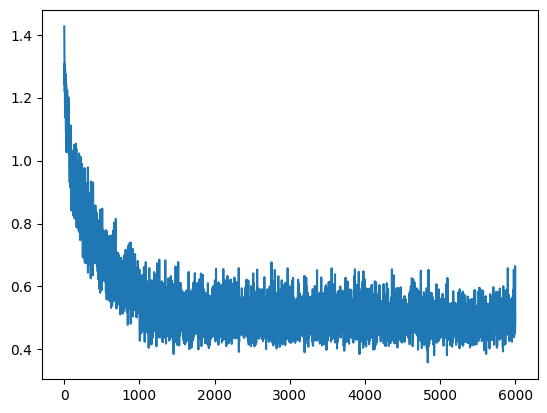

In [35]:
plt.plot(stepi, lossi)

In [36]:
emb=C[Xdev]
h=torch.tanh(emb.view(-1,30) @ w1 + b1)
logits=h @ w2 + b2
loss=F.cross_entropy(logits, Ydev)
print(loss)

tensor(3.1623, grad_fn=<NllLossBackward0>)


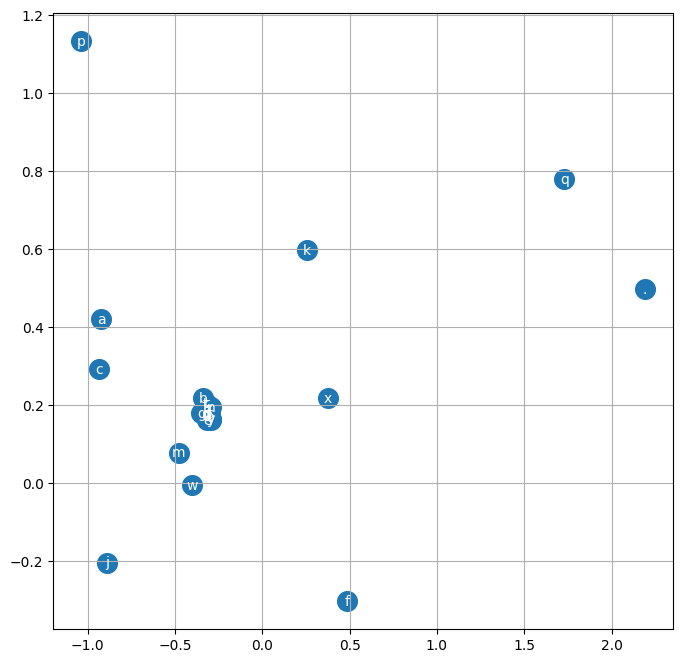

In [37]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')